# PREDICTION OF LC Retention Times

Version 1  
Sept 2026    
TI-Coast  
John Mommers     



## 1 Define ML application

**Goal of this ML model:**  
The script takes a molecule represented as a SMILES string, converts that molecular structure into features that a machine-learning algorithm can use, and then predicts the molecule’s retention time under the LC conditions of the training dataset.

> X = SMILES (smiles.std) --> convert to molecular descriptors  
> y = Retention time (rt)    


**Information about the dataset**  
RepoRT Study 0186 — SMRT_METLIN  

**RepoRT study 0186 (`SMRT_METLIN`)** is the RepoRT version of the **METLIN Small Molecule Retention Time (SMRT) dataset**, originally published by Domingo-Almenara et al. in *Nature Communications* in 2019.

The dataset contains experimental retention times for approximately **80,038 small molecules**, all measured using the same standardized reversed-phase LC-MS method. Because the chromatographic conditions are consistent across the dataset, it is well suited for machine-learning models that predict **retention time (RT) from molecular structure or SMILES**.

LC conditions

* **Chromatography:** Reversed-phase LC
* **Column:** Agilent ZORBAX Extend-C18
* **Column dimensions:** 2.1 × 50 mm
* **Particle size:** 1.8 µm
* **Flow rate:** 0.1 mL/min
* **Mobile phase A:** Water + 0.1% formic acid
* **Mobile phase B:** Acetonitrile + 0.1% formic acid
* **Column temperature:** Not reported in RepoRT

Gradient

| Time (min) | A (%) | B (%) |
| ---------: | ----: | ----: |
|          0 |    95 |     5 |
|          3 |    95 |     5 |
|          5 |    50 |    50 |
|         20 |    15 |    85 |
|         23 |    15 |    85 |

Links

* [RepoRT study 0186 on GitHub](https://github.com/michaelwitting/RepoRT/tree/master/processed_data/0186)
* [Original METLIN SMRT publication](https://www.nature.com/articles/s41467-019-13680-7)
* [Original METLIN SMRT dataset on Figshare](https://doi.org/10.6084/m9.figshare.8038913)


## 2 Load data

In [1]:
# load the dataset 01886 directly from RepoRT GitHub
import pandas as pd

url = (
    "https://raw.githubusercontent.com/"
    "michaelwitting/RepoRT/master/"
    "processed_data/0186/"
    "0186_rtdata_canonical_success.tsv"
)

df = pd.read_csv(url, sep="\t")
df = df[
    ["id", "formula", "smiles.std", "rt"]
].copy()

df

,id,formula,smiles.std,rt
0,0186_00001,C3H8N2S,CCSC(=N)N,1.558333
1,0186_00002,C19H25Cl2N3O3,COC(=O)N1CCN(C(C1)CN2CCCC2)C(=O)CC3=CC(=C(C=C3...,11.463333
2,0186_00003,C17H27N3O4S,CCN1CCCC1CNC(=O)C2=CC(=C(C=C2OC)N)S(=O)(=O)CC,9.845000
3,0186_00004,C9H7NO2,C1=CC2=C(C=CNC2=O)C(=C1)O,9.726667
4,0186_00005,C15H20N2O2,C1CN(CCC12CNC(=O)O2)CCC3=CC=CC=C3,9.650000
...,...,...,...,...
80033,0186_80034,C25H29N3O6S,CCC(=O)NC1=C(ON=C1C)C=CC2=CC=C(C=C2)S(=O)(=O)N...,15.773333
80034,0186_80035,C17H24FN3O5S,COCCCNC(=O)N1CC2CN(CC(C1)O2)S(=O)(=O)C3=CC=CC(...,10.885000
80035,0186_80036,C17H25N3O5S,CC1=CC(=CC=C1)S(=O)(=O)N2CC3CN(CC(C2)O3)C(=O)N...,10.803333
80036,0186_80037,C21H25N3O4S,CC1=CC=C(C=C1)S(=O)(=O)N2CC3CN(CC(C2)O3)C(=O)N...,13.065000


## 3 Explore, standardize and clean

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80038 entries, 0 to 80037
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          80038 non-null  object 
 1   formula     80038 non-null  object 
 2   smiles.std  80038 non-null  object 
 3   rt          80038 non-null  float64
dtypes: float64(1), object(3)
memory usage: 2.4+ MB


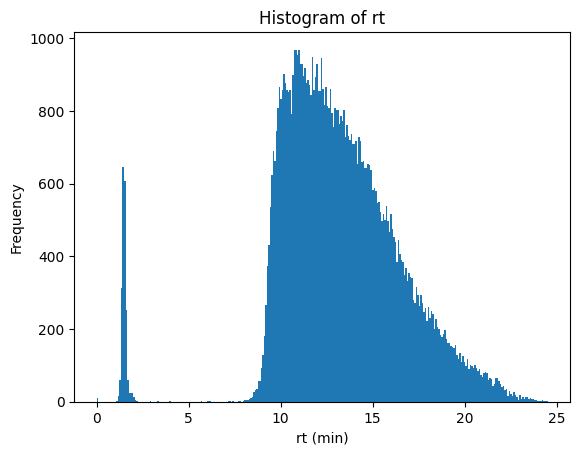

In [3]:
import matplotlib.pyplot as plt

plt.hist(df['rt'], bins=300)
plt.xlabel('rt (min)')
plt.ylabel('Frequency')
plt.title('Histogram of rt')
plt.show()

In [4]:
# Remove entries where rt < 5 minutes
df = df[df['rt'] >= 5].copy()
print(f"Number of entries after filtering: {len(df)}")

Number of entries after filtering: 77980


Now lets look at the SMILES (the molecules)  
- standardize smiles: convert smiles to canonical smiles   
- remove invalid smiles   
- remove duplicates (if not then split on canonical smiles - be aware of data leakage)   

In [5]:
! pip install rdkit # to work with molecules

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 50.1 MB/s eta 0:00:00


In [6]:
# add mol objects to the dataframe df
# smiles are converted to mol objects
from rdkit import Chem
df['molecules'] = df['smiles.std'].apply(Chem.MolFromSmiles)
len(df)

77980

In [7]:
# remove invalid smiles --> a missing mol object
df = df[df['molecules'].notna()]
len(df)

77980

In [8]:
# Standardize smiles: Convert smiles to Canonicolize smiles
df['canonical_smiles'] = df['molecules'].apply(Chem.MolToSmiles)
df

,id,formula,smiles.std,rt,molecules,canonical_smiles
1,0186_00002,C19H25Cl2N3O3,COC(=O)N1CCN(C(C1)CN2CCCC2)C(=O)CC3=CC(=C(C=C3...,11.463333,<rdkit.Chem.rdchem.Mol object at 0x7afd34c8d0e0>,COC(=O)N1CCN(C(=O)Cc2ccc(Cl)c(Cl)c2)C(CN2CCCC2)C1
2,0186_00003,C17H27N3O4S,CCN1CCCC1CNC(=O)C2=CC(=C(C=C2OC)N)S(=O)(=O)CC,9.845000,<rdkit.Chem.rdchem.Mol object at 0x7afd34c8c900>,CCN1CCCC1CNC(=O)c1cc(S(=O)(=O)CC)c(N)cc1OC
3,0186_00004,C9H7NO2,C1=CC2=C(C=CNC2=O)C(=C1)O,9.726667,<rdkit.Chem.rdchem.Mol object at 0x7afd34c8c9e0>,O=c1[nH]ccc2c(O)cccc12
4,0186_00005,C15H20N2O2,C1CN(CCC12CNC(=O)O2)CCC3=CC=CC=C3,9.650000,<rdkit.Chem.rdchem.Mol object at 0x7afd34c8d000>,O=C1NCC2(CCN(CCc3ccccc3)CC2)O1
6,0186_00007,C14H21N3O3,CC(C)(C)NCC(COC1=CC=CC2=C1NC(=O)N2)O,10.051667,<rdkit.Chem.rdchem.Mol object at 0x7afd34c8d070>,CC(C)(C)NCC(O)COc1cccc2[nH]c(=O)[nH]c12
...,...,...,...,...,...,...
80033,0186_80034,C25H29N3O6S,CCC(=O)NC1=C(ON=C1C)C=CC2=CC=C(C=C2)S(=O)(=O)N...,15.773333,<rdkit.Chem.rdchem.Mol object at 0x7afd2c793f40>,CCOc1ccc(OCC)c(NS(=O)(=O)c2ccc(C=Cc3onc(C)c3NC...
80034,0186_80035,C17H24FN3O5S,COCCCNC(=O)N1CC2CN(CC(C1)O2)S(=O)(=O)C3=CC=CC(...,10.885000,<rdkit.Chem.rdchem.Mol object at 0x7afd2c794040>,COCCCNC(=O)N1CC2CN(S(=O)(=O)c3cccc(F)c3)CC(C1)O2
80035,0186_80036,C17H25N3O5S,CC1=CC(=CC=C1)S(=O)(=O)N2CC3CN(CC(C2)O3)C(=O)N...,10.803333,<rdkit.Chem.rdchem.Mol object at 0x7afd2c7940b0>,COCCNC(=O)N1CC2CN(S(=O)(=O)c3cccc(C)c3)CC(C1)O2
80036,0186_80037,C21H25N3O4S,CC1=CC=C(C=C1)S(=O)(=O)N2CC3CN(CC(C2)O3)C(=O)N...,13.065000,<rdkit.Chem.rdchem.Mol object at 0x7afd2c794120>,Cc1ccc(S(=O)(=O)N2CC3CN(C(=O)Nc4ccccc4C)CC(C2)...


In [9]:
# remove duplicates canonical smiles
df = df.drop_duplicates(subset=['canonical_smiles']).copy()
len(df)
print(f"Number of entries after filtering: {len(df)}")

Number of entries after filtering: 77929


## 4 Featurization

What determines LC retention time?
Retention time is determined by how strongly an analyte interacts with the stationary phase compared with how strongly it prefers the mobile phase.
When the LC method is standardized—same column, mobile phase, gradient, pH, flow rate and temperature—the differences in retention time are mainly caused by the analytes’ molecular properties.
Important properties include:
- Lipophilicity: preferably logD at the method pH
- Ionization: pKa and molecular charge at the method pH
- Polarity: for example, topological polar surface area
- Hydrogen bonding: numbers of donors and acceptors
- Molecular size and mass
- Shape and flexibility
- Aromaticity and ring structure
- Specific interactions with the stationary phase  

For reversed-phase LC:  
- Nonpolar analytes usually have longer retention times.
- Polar or ionized analytes generally elute earlier.
- LogD is often more informative than logP because logD accounts for ionization at a particular pH.  

For ML, useful starting features are therefore logD, pKa, charge, TPSA, molecular weight, hydrogen-bond counts, ring counts and rotatable bonds. Even with a standardized method, column ageing, instrument variation, sample matrix and injection solvent can introduce small retention-time shifts.  

We will use the following features:  
- MW  
- LogP  
- TPSA  
- HBD  
- HBA  
- Rotatable bonds  
- Ring count  
- Aromatic Rings
- FractionCSP3  
- HeavyAtomCount  
- FormalCharge  

- Substructure info (fingerprint)




In [10]:
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator

from tqdm.auto import tqdm

In [11]:
# Convert SMILES to RDKit molecules
molecules = [Chem.MolFromSmiles(smiles) for smiles in df["smiles.std"]]

In [12]:
df["MolWt"] = [Descriptors.MolWt(mol) for mol in molecules]
df["LogP"] = [Crippen.MolLogP(mol) for mol in molecules]
df["TPSA"] = [rdMolDescriptors.CalcTPSA(mol) for mol in molecules]

df["HBD"] = [rdMolDescriptors.CalcNumHBD(mol) for mol in molecules]
df["HBA"] = [rdMolDescriptors.CalcNumHBA(mol) for mol in molecules]

df["RotatableBonds"] = [
    rdMolDescriptors.CalcNumRotatableBonds(mol)
    for mol in molecules
]

df["RingCount"] = [
    rdMolDescriptors.CalcNumRings(mol)
    for mol in molecules
]

df["AromaticRings"] = [
    rdMolDescriptors.CalcNumAromaticRings(mol)
    for mol in molecules
]

df["FractionCSP3"] = [
    rdMolDescriptors.CalcFractionCSP3(mol)
    for mol in molecules
]

df["HeavyAtomCount"] = [
    mol.GetNumHeavyAtoms()
    for mol in molecules
]

df["FormalCharge"] = [
    Chem.GetFormalCharge(mol)
    for mol in molecules
]

In [13]:
# Molecular Structure Information
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=1024
)

In [14]:
# Convert a molecule into a binary fingerprint, for example: ...1000100001000110000...
# Each bit indicates the presence or absence of a particular molecular substructure.

import numpy as np

fingerprints = []

for mol in molecules:
    fp = morgan_generator.GetFingerprint(mol)

    array = np.zeros(1024, dtype=int)

    DataStructs.ConvertToNumpyArray(
        fp,
        array
    )

    fingerprints.append(array)

In [15]:
# Put this fingerprints (features) into a dataframe
df_fingerprint = pd.DataFrame(fingerprints)

In [16]:
# Combine features with the Morgan Fingerprints

# X = features + Morgan fingerprint --> 11 + 1024 = 1035 features !!!
# y = rt

from sklearn.model_selection import train_test_split

# Molecular features
features = df[
    [
        "MolWt",
        "LogP",
        "TPSA",
        "HBD",
        "HBA",
        "RotatableBonds",
        "RingCount",
        "AromaticRings",
        "FractionCSP3",
        "HeavyAtomCount",
        "FormalCharge"
    ]
]

# Combine features + Morgan fingerprint
X = pd.concat(
    [features.reset_index(drop=True),
     df_fingerprint.reset_index(drop=True)],
    axis=1
)

# Convert all column names to string type
X.columns = X.columns.astype(str)

# Target: retention time
y = df["rt"]

## 5 Split data

In [17]:
# Split into training and test data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(62343, 1035)
(15586, 1035)


Train-test split options

**Random split**  
The dataset is randomly divided into a training set and a test set. This is simple and useful as a baseline, but very similar molecules can end up in both sets, which may make the model performance look better than it really is.

**Stratified split (better)**  
A stratified split keeps the retention-time distribution similar in the training and test sets. Because retention time is continuous, the RT values are first divided into bins. This gives a more balanced split than a fully random split.

**Scaffold split (best)**  
A scaffold split separates molecules based on their core chemical structure. Molecules with the same or very similar scaffold are kept in the same group. This makes the test set chemically more different from the training set and gives a more realistic measure of how well the model can predict retention times for new types of molecules.

For retention-time prediction from SMILES, a scaffold split is usually the most useful final evaluation, while a random or stratified split can be used as a baseline.



## 6  Choose and built model

Model selection

For this retention-time prediction problem, it is useful to compare several different model types.  

The main model types from simple to more advanced are:  
Linear model → SVR → Random Forest → Gradient Boosting → Neural Network → GNN → Transformer  

**Random Forest**  
A good simple baseline model. It can handle nonlinear relationships and does not require feature scaling, but it may perform less well with a large number of fingerprint features.

**CatBoost**  
A strong choice for the combination of molecular descriptors and the 1024-bit Morgan fingerprint. CatBoost can model complex interactions between features and usually works well without much preprocessing.

**Feed-forward neural network (MLP)**  
A neural network can also be trained using the descriptors and Morgan fingerprint as input. It may learn more complex relationships, but it requires more tuning and does not necessarily outperform CatBoost.

**Graph neural network / ChemProp**  
A more advanced deep-learning approach that learns directly from the molecular structure instead of relying mainly on predefined fingerprints. This is especially interesting for testing whether learned molecular representations improve retention-time prediction.

A good comparison would therefore be:

1. Random Forest — baseline
2. CatBoost — main classical machine-learning model
3. MLP — simple deep-learning model
4. ChemProp / graph neural network — advanced molecular deep learning

The models should be evaluated using the same train-test split and metrics such as MAE, RMSE and R².

## 7 Train model

MODEL 1: Random Forest

In [18]:
from sklearn.ensemble import RandomForestRegressor

# Model
model = RandomForestRegressor(
    n_estimators=100,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_features='sqrt', n_jobs=-1, random_state=42)

## 8 Evaluate model

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions
y_pred = model.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))

MAE: 0.973
RMSE: 1.388
R²: 0.775


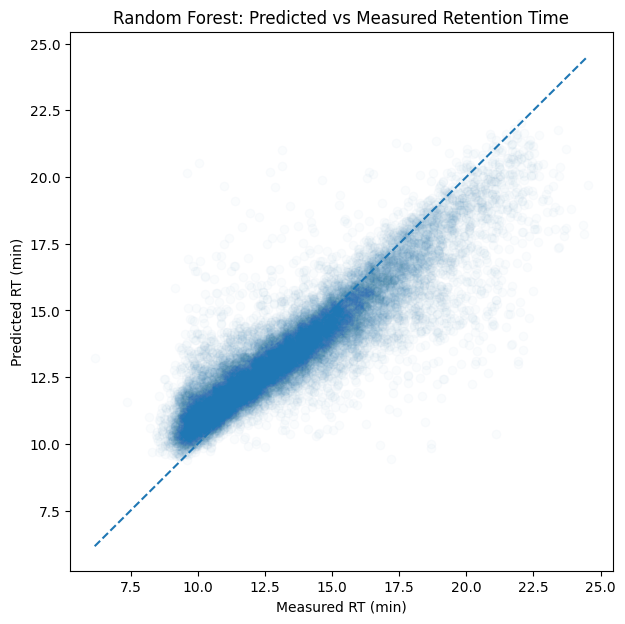

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Random Forest predictions
plt.scatter(
    y_test,
    y_pred,
    alpha=0.02
)

# Perfect prediction line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--"
)

plt.xlabel("Measured RT (min)")
plt.ylabel("Predicted RT (min)")
plt.title("Random Forest: Predicted vs Measured Retention Time")

plt.show()

## 9 Improve model

Test other (more advanced) models   

Add more relevant or missing features !?  
Which molecular features correlate with chromatographic retention in LC?   


>add SMILES --> logD at pH ~3
>add SMILES --> pKa    
>add SMILES --> Solvation parameters  



MODEL 2: Catboost

In [21]:
!pip -q install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.6 MB/s eta 0:00:00


In [22]:
from catboost import CatBoostRegressor

model_cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    verbose=100,
    random_seed=42
)

model_cat.fit(X_train, y_train)

0:	learn: 2.8515653	total: 670ms	remaining: 11m 9s
100:	learn: 1.7526286	total: 31.9s	remaining: 4m 43s
200:	learn: 1.5801343	total: 57.4s	remaining: 3m 48s
300:	learn: 1.4631199	total: 1m 34s	remaining: 3m 40s
400:	learn: 1.3808665	total: 2m 6s	remaining: 3m 9s
500:	learn: 1.3187857	total: 2m 32s	remaining: 2m 31s
600:	learn: 1.2689884	total: 2m 59s	remaining: 1m 58s
700:	learn: 1.2274656	total: 3m 25s	remaining: 1m 27s
800:	learn: 1.1912142	total: 3m 50s	remaining: 57.3s
900:	learn: 1.1593275	total: 4m 16s	remaining: 28.2s
999:	learn: 1.1310975	total: 4m 41s	remaining: 0us


CatBoostRegressor(depth=8, iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [23]:
y_pred_cat = model_cat.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_cat)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2 = r2_score(y_test, y_pred_cat)

print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))

MAE: 0.831
RMSE: 1.241
R²: 0.82


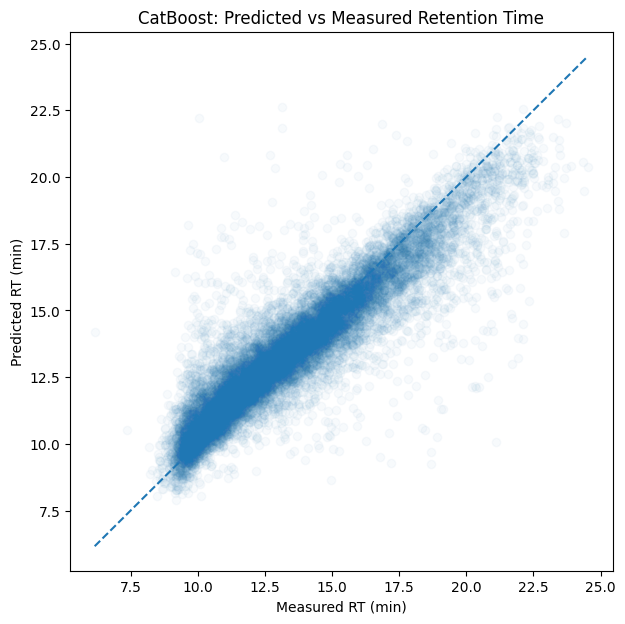

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Predictions
plt.scatter(
    y_test,
    y_pred_cat,
    alpha=0.03
)

# Perfect prediction line
minimum = min(y_test.min(), y_pred_cat.min())
maximum = max(y_test.max(), y_pred_cat.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--"
)

plt.xlabel("Measured RT (min)")
plt.ylabel("Predicted RT (min)")
plt.title("CatBoost: Predicted vs Measured Retention Time")

plt.show()

MODEL 3: XGBoost

In [27]:
pip -q install xgboost

In [28]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    objective='reg:squarederror',
    n_jobs=-1,
    random_state=42
)

model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [29]:
y_pred_xgb = model_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("MAE (XGBoost):", round(mae_xgb, 3))
print("RMSE (XGBoost):", round(rmse_xgb, 3))
print("R² (XGBoost):", round(r2_xgb, 3))

MAE (XGBoost): 0.724
RMSE (XGBoost): 1.146
R² (XGBoost): 0.846


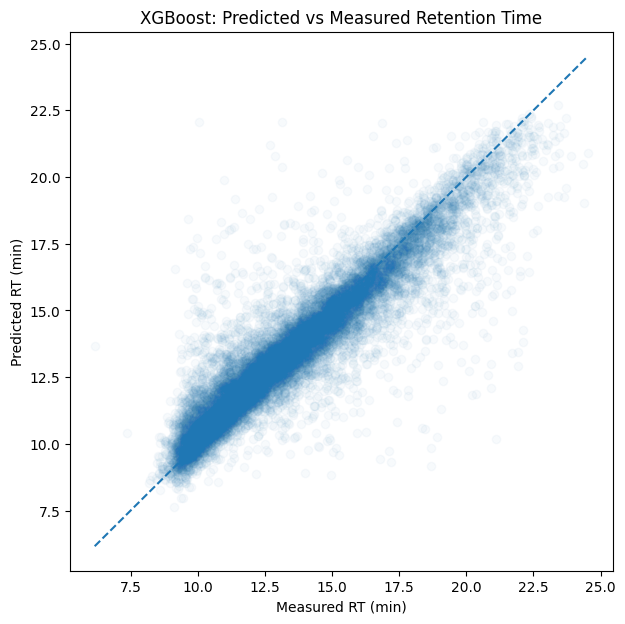

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Predictions
plt.scatter(
    y_test,
    y_pred_xgb,
    alpha=0.03
)

# Perfect prediction line
minimum_xgb = min(y_test.min(), y_pred_xgb.min())
maximum_xgb = max(y_test.max(), y_pred_xgb.max())

plt.plot(
    [minimum_xgb, maximum_xgb],
    [minimum_xgb, maximum_xgb],
    "--"
)

plt.xlabel("Measured RT (min)")
plt.ylabel("Predicted RT (min)")
plt.title("XGBoost: Predicted vs Measured Retention Time")

plt.show()

Based on our evaluation, XGBoost demonstrated the best performance among the models we trained. It achieved the lowest MAE and RMSE, and the highest R² value. This concludes our analysis of predicting LC retention times using the provided dataset and various machine learning models.  

Here's a summary of their performance on the test set:

- Random Forest:  

>MAE: 0.973  
>RMSE: 1.388  
>R²: 0.775    

- CatBoost:  

>MAE: 0.831  
>RMSE: 1.241  
>R²: 0.820  

- XGBoost:  

>MAE: 0.724  
>RMSE: 1.146  
>R²: 0.846  


## 10 Save model

In [31]:
# save the model + model weights for later use !!
import joblib

# Save the best performing model (XGBoost)
joblib.dump(model_xgb, 'xgboost_retention_time_model.pkl')
print("XGBoost model saved as 'xgboost_retention_time_model.pkl'")

XGBoost model saved as 'xgboost_retention_time_model.pkl'


## 11 Deploy model

In [32]:
import joblib
import pandas as pd
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors, rdFingerprintGenerator

# Load the saved XGBoost model
loaded_model = joblib.load('xgboost_retention_time_model.pkl')
print("Model loaded successfully!")

Model loaded successfully!


In [33]:
def featurize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES string: {smiles}")

    # Calculate molecular descriptors
    features = {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "RotatableBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "RingCount": rdMolDescriptors.CalcNumRings(mol),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "HeavyAtomCount": mol.GetNumHeavyAtoms(),
        "FormalCharge": Chem.GetFormalCharge(mol)
    }

    # Generate Morgan fingerprint
    morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
        radius=2,
        fpSize=1024
    )
    fp = morgan_generator.GetFingerprint(mol)
    array = np.zeros(1024, dtype=int)
    DataStructs.ConvertToNumpyArray(fp, array)
    df_fingerprint = pd.DataFrame([array])

    # Combine all features into a single DataFrame
    combined_features = pd.concat(
        [pd.DataFrame([features]), df_fingerprint.set_axis(range(1024), axis=1)],
        axis=1
    )
    # Ensure column names are strings for consistency with the trained model
    combined_features.columns = combined_features.columns.astype(str)
    return combined_features

print("Featurization function defined.")

Featurization function defined.


#### Example Usage

In [36]:
# Example SMILES input
sample_smiles = "C1=CC2=C(C=CNC2=O)C(=C1)O"

# Featurize the SMILES
input_features = featurize_smiles(sample_smiles)

# Make a prediction
predicted_rt = loaded_model.predict(input_features)[0]

print(f"For SMILES '{sample_smiles}', the predicted retention time is: {predicted_rt:.3f} minutes")

For SMILES 'C1=CC2=C(C=CNC2=O)C(=C1)O', the predicted retention time is: 10.949 minutes
